# Atividade LAB - Aula 4

Você deve definir o melhor trajeto de uma aeronave na entrega de suprimentos, admitindo que existem 7 bases. Nesse cenário, a aeronave deve percorrer todas as bases pelo melhor caminho possível, sendo que o menor caminho é o mais viável.

💡Econômia inteligente de bateria deve ser trabalhada

Use Algoritmo Genético para resolver esse problema.

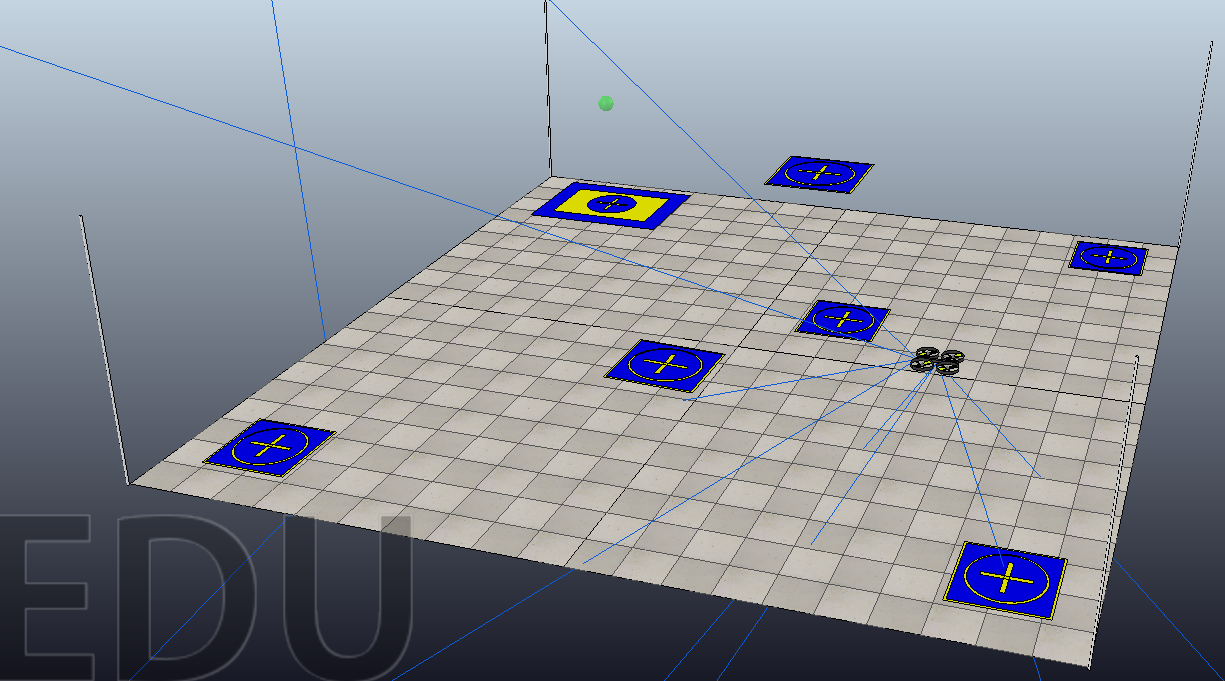

🔴 Não será necessário rodar a simulação em ambiente virtual.

Porém .....

[Simulador](https://www.coppeliarobotics.com/)


In [ ]:
## Baixar Cena (APENAS SE QUISER TESTAR NO SIMULADOR)
import requests

def download_file(url, filename):
  try:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(filename, 'wb') as file:
      for chunk in response.iter_content(chunk_size=8192):
        file.write(chunk)
    print(f"File '{filename}' downloaded successfully.")

  except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")

file_url = "https://raw.githubusercontent.com/AdsonNAlves/scenarios_coppelia_uav/master/scenario_free_short.ttt"
file_name = "scenario_free_short.ttt"
download_file(file_url, file_name)



## ATIVIDADE

Considerere as seguintes referências.

```
          ,x,      y,     z
p1,   -2.750, -1.700, 0.100
p2,    1.250,  4.899, 1.000
p3,    0.180,  2.774, 2.550
p4,   -2.750,  6.400, 0.100
p5,    5.300,  6.375, 0.100
p6,    0.250,  1.400, 0.100
p7,    4.775, -1.525, 0.100
```


Passo 0 -> Exemplo de Caminho [p1, p2, p3, p4, p5, p6, p7] <- Individuo

Passo 1 - Definir a quantidade de individuos da sua população Ex:(6)

Passo 2 - Gerar de forma random caminhos prováveis Ex: (6 caminhos)

Passo 3 - Identificar o valor de aptidão de cada Individuo(Valor de Caminho/ Trajeto)

Passo 4 - Organizar do menor valor para maior valor (distancia total percorrida)

Passo 5 - Escolher 2 Individuos com os menores valores (distancia total percorrida)

Passo 6 - Fazer o crossover com os 2 individuos. Para isso definir um ponto de crossover de forma
randomica e gerar a permutação dos valores a direta da lista que representa o caminho. (ATENÇÃO, NAO PODE TER "P" REPETIDO)

PASSO 7 - FAZER A MUTAÇÃO (SORTEAR PONTOS RANDOMICAMENTE)

PASSO 8 - Identificar o valor de aptidão dos novos Individuos(filhos)

Passo 9 - Identificar os individuos com menor aptidão (caminho mais longo) e substitui-los pelos caminhos filhos gerados

Passo 10 - Verificar criterio de parada (quant. de iterações | Valor da distancia < que X)

Passo 11 - Se o criterio atendeu parar treinamento

In [ ]:
import math
import random

random.seed(42)

In [ ]:
# Passo 0: Exemplo de Caminho [p1, p2, p3, p4, p5, p6, p7]
p1 = [-2.750, -1.700, 0.100]
p2 = [1.250, 4.899, 1.000]
p3 = [0.180, 2.774, 2.550]
p4 = [-2.750, 6.400, 0.100]
p5 = [5.300, 6.375, 0.100]
p6 = [0.250, 1.400, 0.100]
p7 = [4.775, -1.525, 0.100]

pontos = [p1, p2, p3, p4, p5, p6, p7]

In [ ]:
# Passo 1: Definindo a quantidade de indivíduos na população
num_individuos = 50

In [ ]:
# Passo 2: Gerar caminhos aleatórios
def gerar_populacao(num_individuos, pontos):
    caminhos = []
    for _ in range(num_individuos):
        caminho = pontos[:]
        random.shuffle(caminho)
        caminhos.append(caminho)
    return caminhos

populacao = gerar_populacao(num_individuos, pontos)

for i, caminho in enumerate(populacao):
    print(f"Caminho {i + 1}: {caminho}")

Caminho 1: [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Caminho 2: [[-2.75, 6.4, 0.1], [4.775, -1.525, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1], [1.25, 4.899, 1.0]]
Caminho 3: [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Caminho 4: [[0.18, 2.774, 2.55], [0.25, 1.4, 0.1], [-2.75, -1.7, 0.1], [-2.75, 6.4, 0.1], [4.775, -1.525, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1]]
Caminho 5: [[4.775, -1.525, 0.1], [-2.75, 6.4, 0.1], [0.25, 1.4, 0.1], [1.25, 4.899, 1.0], [-2.75, -1.7, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1]]
Caminho 6: [[0.25, 1.4, 0.1], [-2.75, -1.7, 0.1], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [4.775, -1.525, 0.1], [0.18, 2.774, 2.55]]


In [ ]:
# Passo 3: Identificar o valor de aptidão de cada Individuo
def calcular_distancia(ponto1, ponto2):
  return math.sqrt(
    (ponto2[0] - ponto1[0]) ** 2 +
    (ponto2[1] - ponto1[1]) ** 2 +
    (ponto2[2] - ponto1[2]) ** 2
  )

def calcular_aptidao(caminho):
  distancia_total = 0

  for i in range(len(caminho) - 1):
    distancia_total += calcular_distancia(caminho[i], caminho[i + 1])

  return distancia_total

In [ ]:
# Passo 4: Organizar do menor valor para maior valor
def ordenar_aptidao(caminhos):
    return sorted(caminhos, key=calcular_aptidao)

populacao_ordenada = ordenar_aptidao(populacao)

print("\nCaminhos ordenados por aptidão:")
for i, individuo in enumerate(populacao_ordenada):
  aptidao = calcular_aptidao(individuo)
  print(f"Indivíduo {i + 1}: Aptidão = {aptidao:.3f} | Caminho {i + 1}: {individuo}")


Caminhos ordenados por aptidão:
Indivíduo 1: Aptidão = 33.056 | Caminho 1: [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Indivíduo 2: Aptidão = 37.732 | Caminho 2: [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Indivíduo 3: Aptidão = 37.938 | Caminho 3: [[0.18, 2.774, 2.55], [0.25, 1.4, 0.1], [-2.75, -1.7, 0.1], [-2.75, 6.4, 0.1], [4.775, -1.525, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1]]
Indivíduo 4: Aptidão = 39.003 | Caminho 4: [[0.25, 1.4, 0.1], [-2.75, -1.7, 0.1], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [4.775, -1.525, 0.1], [0.18, 2.774, 2.55]]
Indivíduo 5: Aptidão = 40.882 | Caminho 5: [[4.775, -1.525, 0.1], [-2.75, 6.4, 0.1], [0.25, 1.4, 0.1], [1.25, 4.899, 1.0], [-2.75, -1.7, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1]]
Indivíduo 6: Aptidão = 43.868 | Caminho 6: [[-2.75, 

In [ ]:
# Passo 5: Escolher 2 Individuos com os menores valores (distancia total percorrida)
def selecionar_melhores_individuos(caminhos):
    return caminhos[:2]

melhores_individuos = selecionar_melhores_individuos(populacao_ordenada)

print("\nMelhores indivíduos selecionados para crossover:")
for i, caminho in enumerate(melhores_individuos):
    aptidao = calcular_aptidao(caminho)
    print(f"Melhor {i + 1}: Aptidão = {aptidao:.3f} | Caminho = {caminho}")


Melhores indivíduos selecionados para crossover:
Melhor 1: Aptidão = 33.056 | Caminho = [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Melhor 2: Aptidão = 37.732 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]


In [ ]:
# Passo 6: Fazer o crossover com os 2 individuos. Para isso definir um ponto de crossover de forma randomica e gerar a permutação dos valores a direta da lista que representa o caminho
def crossover(pai1, pai2):
  tamanho = len(pai1)
  ponto_crossover = random.randint(1, tamanho - 2)
  filho = pai1[:ponto_crossover]

  for ponto in pai2:
    if ponto not in filho:
      filho.append(ponto)

  return filho

pai1, pai2 = melhores_individuos
filho1 = crossover(pai1, pai2)
filho2 = crossover(pai2, pai1)

print("\nCrossover realizado:")
print(f"Pai 1: Aptidão: {calcular_aptidao(pai1):.3f} | Caminho = {pai1}")
print(f"Pai 2: Aptidão: {calcular_aptidao(pai2):.3f} | Caminho = {pai2}")
print(f"Filho 1: Aptidão: {calcular_aptidao(filho1):.3f} | Caminho = {filho1}")
print(f"Filho 2: Aptidão: {calcular_aptidao(filho2):.3f} | Caminho = {filho2}")


Crossover realizado:
Pai 1: Aptidão: 33.056 | Caminho = [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Pai 2: Aptidão: 37.732 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Filho 1: Aptidão: 34.085 | Caminho = [[-2.75, 6.4, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Filho 2: Aptidão: 36.359 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]


In [ ]:
# Passo 7: FAZER A MUTAÇÃO (SORTEAR PONTOS RANDOMICAMENTE)
def mutacao(individuo, taxa_mutacao=0.1):
    if random.random() < taxa_mutacao:
      tamanho = len(individuo)

      i, j = random.sample(range(tamanho), 2)
      individuo[i], individuo[j] = individuo[j], individuo[i]
    return individuo

filho1_mutante = mutacao(filho1)
filho2_mutante = mutacao(filho2)

# Passo 8: Identificar o valor de aptidão dos novos Individuos(filhos)
print("\nFilhos após mutação:")
print(f"Filho 1 Mutante: Aptidão: {calcular_aptidao(filho1_mutante):.3f} | Caminho = {filho1_mutante}")
print(f"Filho 2 Mutante: Aptidão: {calcular_aptidao(filho2_mutante):.3f} | Caminho = {filho2_mutante}")


Filhos após mutação:
Filho 1 Mutante: Aptidão: 34.085 | Caminho = [[-2.75, 6.4, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Filho 2 Mutante: Aptidão: 36.359 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]


In [ ]:
# Passo 9: Identificar os individuos com menor aptidão (caminho mais longo) e substitui-los pelos caminhos filhos gerados
def substituir_individuos(nova_populacao, novos_individuos):
  for i in range(len(novos_individuos)):
    nova_populacao.append(novos_individuos[i])

  nova_populacao_ordenada = ordenar_aptidao(nova_populacao)
  return nova_populacao_ordenada[:-2]

nova_populacao_ordenada = substituir_individuos(populacao_ordenada.copy(), [filho1_mutante, filho2_mutante])

print("\nNova população após substituição dos piores indivíduos:")
for i, individuo in enumerate(nova_populacao_ordenada):
    print(f"Indivíduo {i+1}: Aptidão = {calcular_aptidao(individuo):.3f} | Caminho = {individuo}")


Nova população após substituição dos piores indivíduos:
Indivíduo 1: Aptidão = 33.056 | Caminho = [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [1.25, 4.899, 1.0], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Indivíduo 2: Aptidão = 34.085 | Caminho = [[-2.75, 6.4, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Indivíduo 3: Aptidão = 36.359 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [5.3, 6.375, 0.1], [0.25, 1.4, 0.1], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1]]
Indivíduo 4: Aptidão = 37.732 | Caminho = [[1.25, 4.899, 1.0], [-2.75, 6.4, 0.1], [5.3, 6.375, 0.1], [0.18, 2.774, 2.55], [4.775, -1.525, 0.1], [-2.75, -1.7, 0.1], [0.25, 1.4, 0.1]]
Indivíduo 5: Aptidão = 37.938 | Caminho = [[0.18, 2.774, 2.55], [0.25, 1.4, 0.1], [-2.75, -1.7, 0.1], [-2.75, 6.4, 0.1], [4.775, -1.525, 0.1], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1]]
Indivíduo 6: Aptidão = 39.003 | C

In [ ]:
# Algoritmo Generico
def algoritmo_genetico(pontos, tamanho_populacao=6, num_iteracoes=250, taxa_mutacao=0.1):
  populacao = gerar_populacao(tamanho_populacao, pontos)
  # print("\nPopulação inicial:")
  # for i, individuo in enumerate(populacao):
    # print(f"Indivíduo {i+1}: Aptidão = {calcular_aptidao(individuo):.3f} | Caminho = {individuo}")

  for _ in range(num_iteracoes):
    populacao_ordenada = ordenar_aptidao(populacao)

    melhores_individuos = selecionar_melhores_individuos(populacao_ordenada)

    filho1 = crossover(melhores_individuos[0], melhores_individuos[1])
    filho2 = crossover(melhores_individuos[1], melhores_individuos[0])

    filho1_mutante = mutacao(filho1, taxa_mutacao)
    filho2_mutante = mutacao(filho2, taxa_mutacao)

    populacao = substituir_individuos(populacao_ordenada.copy(), [filho1_mutante, filho2_mutante])
    # print("\nPopulação após iteração:")
    # for i, individuo in enumerate(populacao):
    #   print(f"Indivíduo {i+1}: Aptidão = {calcular_aptidao(individuo):.3f} | Caminho = {individuo}")

  melhor_individuo = min(populacao, key=calcular_aptidao)
  return melhor_individuo, calcular_aptidao(melhor_individuo)

# algoritmo_genetico(pontos, tamanho_populacao=num_individuos)
melhor_caminho, melhor_distancia = algoritmo_genetico(pontos, tamanho_populacao=num_individuos)
print("Melhor caminho encontrado:", melhor_caminho)
print("Distância total:", melhor_distancia)

Melhor caminho encontrado: [[-2.75, 6.4, 0.1], [0.18, 2.774, 2.55], [1.25, 4.899, 1.0], [5.3, 6.375, 0.1], [4.775, -1.525, 0.1], [0.25, 1.4, 0.1], [-2.75, -1.7, 0.1]]
Distância total: 30.12892755699523
